# Label Attacks

## Label Flipping
Label Flipping is a simple data poisoning attack where an adversary changes the labels of training data points while leaving the features intact, causing the model to learn incorrect associations and degrading overall performance. It targets the integrity of stored datasets and aligns with OWASP LLM03: Training Data Poisoning.

**Our example:** In this example, an attacker flips labels on customer reviews so a sentiment model trained on the poisoned data becomes unreliable and reports the wrong overall sentiment. The company then makes costly wrong decisions (pulling a successful product or “fixing” popular features) based on the corrupted analysis.

### Environment Setup
To demonstrate how such an attack would work, we will build a model around the sentiment analysis scenario. A company is training a model to classify customer feedback as positive or negative, and we, as the adversary, will attack the training dataset by flipping labels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

htb_green = "#9fef00"
node_black = "#141d2b"
hacker_grey = "#a4b1cd"
white = "#ffffff"
azure = "#0086ff"
nugget_yellow = "#ffaf00"
malware_red = "#ff3e3e"
vivid_purple = "#9f00ff"
aquamarine = "#2ee7b6"

# Configure plot styles
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams.update(
    {
        "figure.facecolor": node_black,
        "axes.facecolor": node_black,
        "axes.edgecolor": hacker_grey,
        "axes.labelcolor": white,
        "text.color": white,
        "xtick.color": hacker_grey,
        "ytick.color": hacker_grey,
        "grid.color": hacker_grey,
        "grid.alpha": 0.1,
        "legend.facecolor": node_black,
        "legend.edgecolor": hacker_grey,
        "legend.frameon": True,
        "legend.framealpha": 1.0,
        "legend.labelcolor": white,
    }
)

# Seed for reproducibility
SEED = 1337
np.random.seed(SEED)

print("Setup complete. Libraries imported and styles configured.")

Setup complete. Libraries imported and styles configured.


### The Dataset
We use Scikit-Learn’s `make_blobs` to generate a simple 2D synthetic dataset of two well-separated clusters that stand in for numerical features extracted from customer reviews. One cluster represents negative sentiment (Class 0) and the other positive (Class 1), making the effect of label flipping easy to visualize on the decision boundary.

In [2]:
# Generate synthetic data
n_samples = 1000
centers = [(0, 5), (5, 0)]  # Define centers for two distinct blobs
X, y = make_blobs(
    n_samples=n_samples,
    centers=centers,
    n_features=2,
    cluster_std=1.25,
    random_state=SEED,
)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED
)

print(f"Generated {n_samples} samples.")
print(f"Training set size: {X_train.shape[0]} samples.")
print(f"Testing set size: {X_test.shape[0]} samples.")
print(f"Number of features: {X_train.shape[1]}")
print(f"Classes: {np.unique(y)}")

Generated 1000 samples.
Training set size: 700 samples.
Testing set size: 300 samples.
Number of features: 2
Classes: [0 1]


### Plot the Dataset

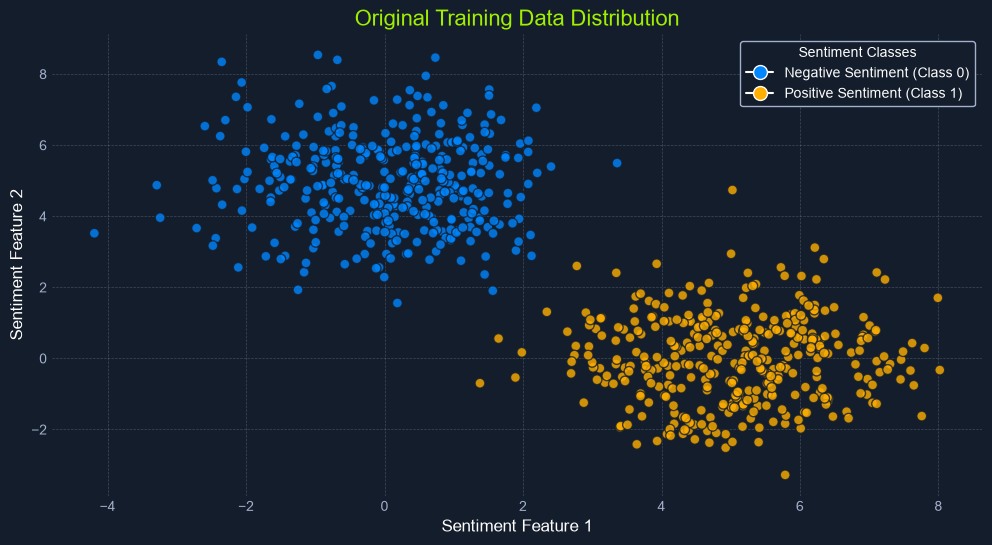

In [3]:
def plot_data(X, y, title="Dataset Visualization"):
    """
    Plots the 2D dataset with class-specific colors.

    Parameters:
    - X (np.ndarray): Feature data (n_samples, 2).
    - y (np.ndarray): Labels (n_samples,).
    - title (str): The title for the plot.
    """
    plt.figure(figsize=(12, 6))
    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.8,
    )
    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Sentiment Feature 1", fontsize=12)
    plt.ylabel("Sentiment Feature 2", fontsize=12)
    # Create a legend
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Negative Sentiment (Class 0)", 
            markersize=10,
            markerfacecolor=azure,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Positive Sentiment (Class 1)",
            markersize=10,
            markerfacecolor=nugget_yellow,
        ),
    ]
    plt.legend(handles=handles, title="Sentiment Classes")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()


# Plot the data
plot_data(X_train, y_train, title="Original Training Data Distribution")

### Baseline Logistic Regression Model
**Baseline setup:** Train a Logistic Regression classifier on the clean training data (X_train, y_train) to measure normal, non-adversarial performance for later comparison against a poisoned model.

**Model mechanics:** It computes a linear logit z = w^T x + b, converts it to a probability via the sigmoid, and optimizes binary cross-entropy loss to learn weights w and bias b; predictions use a 0.5 threshold, forming a linear decision boundary.

**Next step:** Fit the model on the clean data and report its accuracy on the held-out test set.

Baseline Model Accuracy: 0.9933


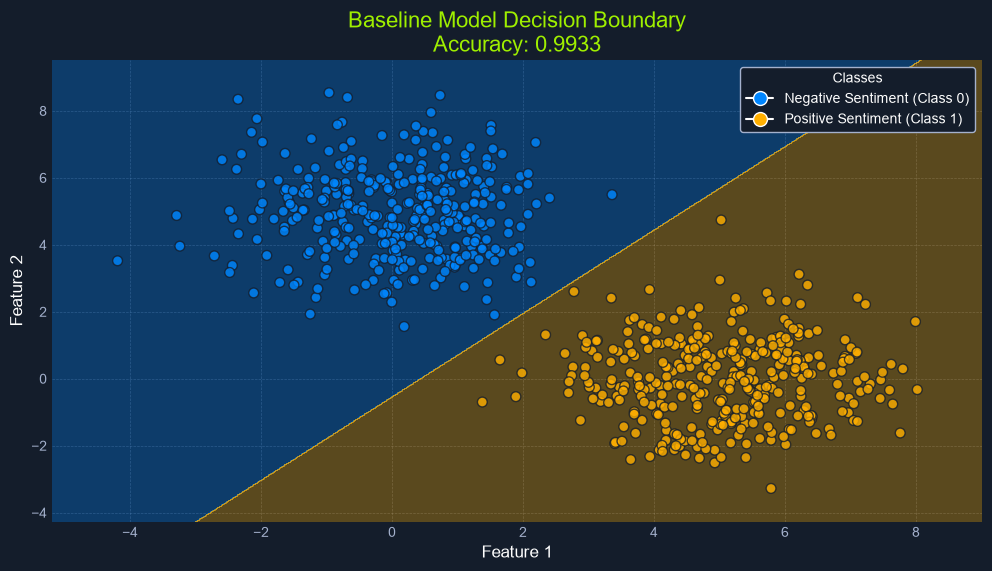

In [4]:
# Initialize and train the Logistic Regression model
baseline_model = LogisticRegression(random_state=SEED)
baseline_model.fit(X_train, y_train)

# Predict on the test set
y_pred_baseline = baseline_model.predict(X_test)

# Calculate baseline accuracy
baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
print(f"Baseline Model Accuracy: {baseline_accuracy:.4f}")


# Prepare to plot the decision boundary
def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    """
    Plots the decision boundary of a trained classifier on a 2D dataset.

    Parameters:
    - model: The trained classifier object (must have a .predict method).
    - X (np.ndarray): Feature data (n_samples, 2).
    - y (np.ndarray): Labels (n_samples,).
    - title (str): The title for the plot.
    """
    h = 0.02  # Step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the class for each point in the mesh
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(12, 6))
    # Plot the decision boundary contour
    plt.contourf(
        xx, yy, Z, cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]), alpha=0.3
    )

    # Plot the data points
    scatter = plt.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.8,
    )

    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)

    # Create a legend manually
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Negative Sentiment (Class 0)",
            markersize=10,
            markerfacecolor=azure,
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Positive Sentiment (Class 1)",
            markersize=10,
            markerfacecolor=nugget_yellow,
        ),
    ]
    plt.legend(handles=handles, title="Classes")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.show()


# Plot the decision boundary for the baseline model
plot_decision_boundary(
    baseline_model,
    X_train,
    y_train,
    title=f"Baseline Model Decision Boundary\nAccuracy: {baseline_accuracy:.4f}",
)

### The Label Flipping Attack
**Attack execution:** Create a function that takes the original y_train labels and a poisoning percentage, then randomly selects that fraction of training points and flips their labels (0↔1).  

**Effect on learning:** Flipped labels corrupt the binary cross-entropy loss terms, forcing the optimizer to adjust w and b to accommodate the poisoned points and thereby shifting the decision boundary (`wᵀx + b = 0`) away from the true data distribution.

Implement a `flip_labels` function that validates a poison percentage (0–1), computes how many labels to flip, and randomly inverts that fraction of the original `y_train` labels.

In [13]:
def flip_labels(y, poison_percentage):
    if not 0 <= poison_percentage <= 1:
        raise ValueError("poison_percentage must be between 0 and 1.")

    n_samples = len(y)
    n_to_flip = int(n_samples * poison_percentage)

    if n_to_flip == 0:
        print("Warning: Poison percentage is 0 or too low to flip any labels.")
        # Return unchanged labels and empty indices if no flips are needed
        return y.copy(), np.array([], dtype=int)
        
    # Using a seeded NumPy RNG, randomly select `n_to_flip` unique indices (without replacement) that identify which training reviews will have their labels flipped.    
    # Use the defined SEED for the random number generator
    rng_instance = np.random.default_rng(SEED)
    # Select unique indices to flip
    flipped_indices = rng_instance.choice(n_samples, size=n_to_flip, replace=False)

    # Create a copy of the labels (y_poisoned = y.copy()), then invert the selected indices with 1 - y_poisoned[flipped_indices] (or np.where) so the original array stays untouched.
    # Create a copy to avoid modifying the original array
    y_poisoned = y.copy()

    # Get the original labels at the indices we are about to flip
    original_labels_at_flipped = y_poisoned[flipped_indices]

    # Apply the flip: if original was 0, set to 1; otherwise (if 1), set to 0
    y_poisoned[flipped_indices] = np.where(original_labels_at_flipped == 0, 1, 0)

    print(f"Flipping {n_to_flip} labels ({poison_percentage * 100:.1f}%).")

    return y_poisoned, flipped_indices
    

### Plot the Corrupted Data

In [14]:
def plot_poisoned_data(
    X,
    y_original,
    y_poisoned,
    flipped_indices,
    title="Poisoned Data Visualization",
    target_class_info=None,
):
    """
    Plots a 2D dataset, highlighting points whose labels were flipped.

    Parameters:
    - X (np.ndarray): Feature data (n_samples, 2).
    - y_original (np.ndarray): The original labels before flipping (used for context if needed, currently unused in logic but good practice).
    - y_poisoned (np.ndarray): Labels after flipping.
    - flipped_indices (np.ndarray): Indices of the samples that were flipped.
    - title (str): The title for the plot.
    - target_class_info (int, optional): The class label of the points that were targeted for flipping. Defaults to None.
    """
    plt.figure(figsize=(12, 7))

    # Identify non-flipped points
    mask_not_flipped = np.ones(len(y_poisoned), dtype=bool)
    mask_not_flipped[flipped_indices] = False

    # Plot non-flipped points (color by their poisoned label, which is same as original)
    plt.scatter(
        X[mask_not_flipped, 0],
        X[mask_not_flipped, 1],
        c=y_poisoned[mask_not_flipped],
        cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
        edgecolors=node_black,
        s=50,
        alpha=0.6,
        label="Unchanged Label",  # Keep this generic
    )

    # Determine the label for flipped points in the legend
    if target_class_info is not None:
        flipped_legend_label = f"Flipped (Orig Class {target_class_info})"
        # You could potentially use target_class_info to adjust facecolor if needed,
        # but current logic colors by the new label which is often clearer.
    else:
        flipped_legend_label = "Flipped Label"

    # Plot flipped points with a distinct marker and outline
    if len(flipped_indices) > 0:
        # Color flipped points according to their new (poisoned) label
        plt.scatter(
            X[flipped_indices, 0],
            X[flipped_indices, 1],
            c=y_poisoned[flipped_indices],  # Color by the new label
            cmap=plt.cm.colors.ListedColormap([azure, nugget_yellow]),
            edgecolors=malware_red,  # Highlight edge in red
            linewidths=1.5,
            marker="X",  # Use 'X' marker
            s=100,
            alpha=0.9,
            label=flipped_legend_label,  # Use the determined label
        )

    plt.title(title, fontsize=16, color=htb_green)
    plt.xlabel("Feature 1", fontsize=12)
    plt.ylabel("Feature 2", fontsize=12)

    # Create legend
    handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Class 0 Point (Azure)",
            markersize=10,
            markerfacecolor=azure,
            linestyle="None",
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Class 1 Point (Yellow)",
            markersize=10,
            markerfacecolor=nugget_yellow,
            linestyle="None",
        ),
        # Add the flipped legend entry using the label
        plt.Line2D(
            [0],
            [0],
            marker="X",
            color="w",
            label=flipped_legend_label,
            markersize=12,
            markeredgecolor=malware_red,
            markerfacecolor=hacker_grey,
            linestyle="None",
        ),
    ]
    plt.legend(handles=handles, title="Data Points")
    plt.grid(True, color=hacker_grey, linestyle="--", linewidth=0.5, alpha=0.3)
    plt.show()